# Développement d'un perceptron

In [1]:
import numpy as np 
import math 
import matplotlib.pyplot as plt
from numpy import random as rd

In [2]:
import numpy as np
import matplotlib .pyplot as plt
import pandas as pd
import os

### Mise en place d'un perceptron simple

In [3]:
def perceptron_simple(x,w,active) :
    v = w[0]+np.dot(w[1:],x)
    
    if active == 0 :
        if v < 0:
            y = 0
        else :
            y = 1
    elif active == 1:
        if np.tanh(v) < 0 :
            y = 0
        else :
            y = 1
    return np.tanh(y)

### Exemple du OU logique

In [4]:
x= [0,0]
w=[-0.5,1,1]
res = perceptron_simple(x,w,0)
print(res)

0.0


### Représentation graphique

<Figure size 640x480 with 0 Axes>

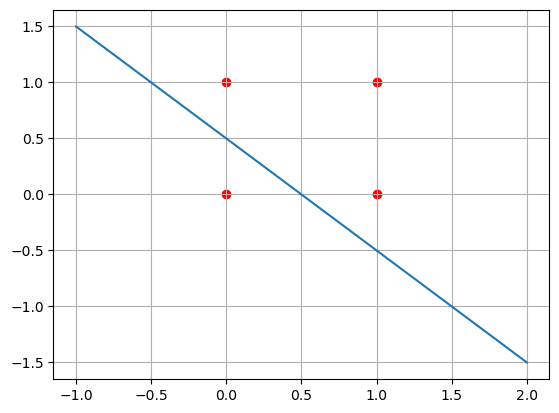

<Figure size 640x480 with 0 Axes>

In [5]:
#pour trouver a et b, on resout w1*a +w2*b +w0 =0
# on trace le graphique

a = -1
b = 0.5
t=[-1,2] 
absi = [0,0,1,1]
ordo = [0,1,0,1]
plt.scatter(absi, ordo, c = 'red')
z=[a*t[0]+b,a*t[1]+b]


plt.grid()
plt.plot(t,z) 
plt.figure()

## Etude de l'apprentissage

### Programmation apprentissage Widrow-hoff

In [6]:
def apprentissage(x,yd,epoch):
    #on définit des poids aleatoires
    #w=[1,0.5,1]
    w=[rd.rand(),rd.rand(),rd.rand()]
    alpha = 0.1
    n=0
    erreur= []
    while n < epoch :
        erreur_epoch = 0
        for j in range(0,3):
            for ind in range (0,data_t.shape[0]) :
                v = np.dot(np.array(w),x[ind])
                y = np.tanh(v)
                deriv = 1 - (y*y)
                w[j] =  (w[j] - alpha*(-(yd[ind]-y)*deriv*x[ind][j]))
                erreur_epoch = erreur_epoch +  (yd[ind]-y)**2
        n = n+1
        erreur_epoch = erreur_epoch/2 
        erreur.append(erreur_epoch)
    return w,erreur 

In [7]:
#Réalisation de l'apprentissage 
#reponse desiree pour chaque element x[:,i].
yd = np.repeat([1,-1],(25,25), axis = 0)

In [8]:
yd

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

### Test 1 simple

Les poids sont :[-1.1082985730465116, 0.2521152092689996, 0.7196408677515317]
Les erreurs successives sont :[150.05440954983544, 149.98346590370824, 149.97952515235187, 149.9750339502721, 149.96860225754446, 149.95760403826844, 149.93223338144676, 149.73878023081977, 142.77426956419114, 149.99999985981535]


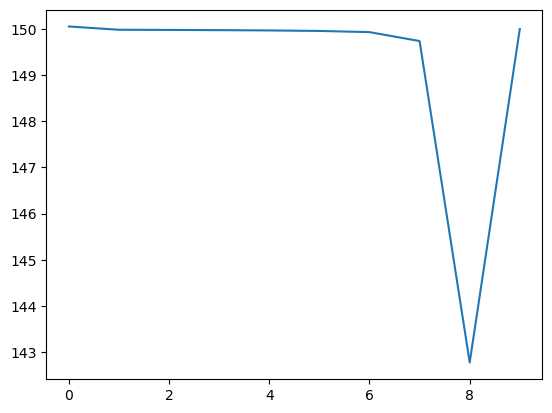

In [9]:
#test 1
data = np.array(np.loadtxt('p2_d1.txt'))
data_t = np.transpose(data)
data_t = np.insert(data_t,0,10,axis=1)
res = apprentissage(data_t,yd,10)
print("Les poids sont :" + str(res[0]))
print("Les erreurs successives sont :" + str(res[1]))
plt.clf()
plt.plot(res[1])

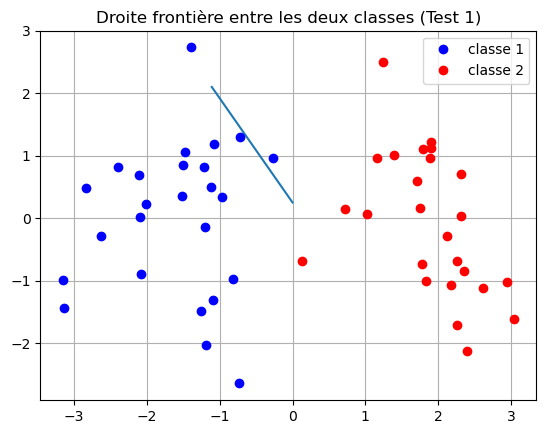

In [10]:
#affichage de la droite frontière grâce aux poids calculés par l'algorithme
plt.plot([res[0][0],0], [2.1,res[0][1]], '-')
plt.title("Droite frontière entre les deux classes (Test 1)")

i = 0
for p in data[0]:
    if i < 25:
        classe1, = plt.plot(p,data[1][i], 'bo', label='classe 1')
    else: classe2, = plt.plot(p,data[1][i], 'ro', label='classe 2')
    i = i+1
plt.legend(handles=[classe1, classe2])
plt.grid()

### Test 2

Les poids sont :[-0.04794218885874659, -1.2938106939547473, -0.10551434923896562]
Les erreurs successives sont :[55.028589895428794, 19.725914990167777, 18.08817029509179, 17.644335019099323, 17.412382228308264, 17.260856984001325, 17.151953936406606, 17.068101529945626, 17.00014302604258, 16.942912782982884]


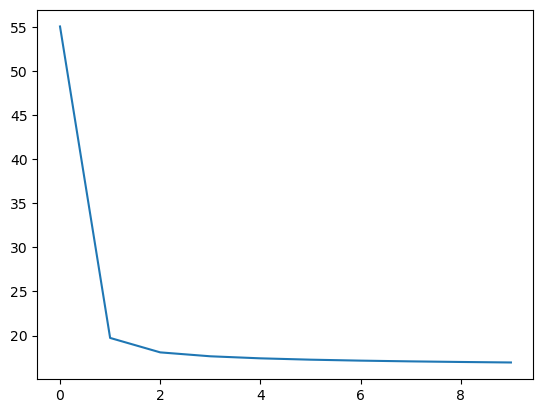

In [11]:
#test 2
data = np.array(np.loadtxt('p2_d2.txt'))
data_t = np.transpose(data)
data_t = np.insert(data_t,0,1,axis=1)
res2 = apprentissage(data_t,yd,10)
print("Les poids sont :" + str(res2[0]))
print("Les erreurs successives sont :" + str(res2[1]))
plt.plot(res2[1])

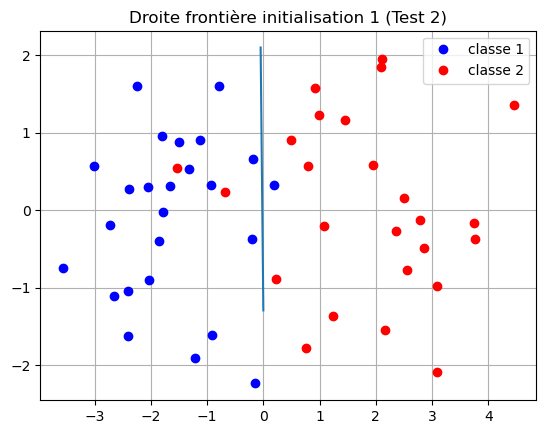

In [12]:
#affichage de la droite frontière grâce aux poids calculés par l'algorithme
plt.plot([res2[0][0],0], [2.1,res2[0][1]], '-')
plt.title("Droite frontière initialisation 1 (Test 2)")

i = 0
for p in data[0]:
    if i < 25:
        classe1, = plt.plot(p,data[1][i], 'bo', label='classe 1')
    else: classe2, = plt.plot(p,data[1][i], 'ro', label='classe 2')
    i = i+1
plt.legend(handles=[classe1, classe2])
plt.grid()

## Perceptron multi-couches

### Mise en place d'un perceptron multicouche

In [13]:
import numpy as np
from matplotlib import pyplot as plt

In [14]:
def multiperceptron(x,w1,w2):
    y= [1]
    for i in range(0,2):
        u = np.dot(w1[i],x)
        y.append( 1 /( 1 + np.exp(-1*u)))
    u_final = np.dot(y,x)
    y_final = 1 /( 1 + np.exp(-1*u_final))
    return y_final,y #sortie du neurone

#### Apliccation à l'exemple ci-dessous :

In [15]:
x = [1,1,1]
w1 = [[-0.5,2,-1],
      [0.5,1,0.5]]
w2 = [2,-1,1]

In [16]:
y = multiperceptron(x,w1,w2)
print(y) #sortie du neurone

(0.9243697912941278, [1, 0.6224593312018546, 0.8807970779778823])


### Programmation apprentissage multicouches

In [17]:
def multiLearn(x,yd,epoch,Batch_size):
    w1 = [[rd.rand(),rd.rand(),rd.rand()],[rd.rand(),rd.rand(),rd.rand()]] #poids aléatoires
    w2= [rd.rand(),rd.rand(),rd.rand()]
    alpha = 0.5
    n=0
    erreur= []
    while n < epoch :
        erreur_epoch = 0
        for ind in range(4):
            yf = multiperceptron(x[ind], w1, w2)
            rf = -1 * (yd[ind] - yf[0]) * (yf[0] - yf[0]**2)
            erreur_epoch = erreur_epoch + (yd[ind]-yf[0])**2
            for i in range(0,2):
                r = 0
                r = w2[i] * rf * yf[1][i+1]
                for poids in range(0,3):
                    w1[i][poids] -=  alpha * r * x[ind][poids]
            for poids in range(0,3):
                w2[poids] -=  alpha * rf * yd[ind]
        n = n+1
        erreur_epoch = erreur_epoch/2 
        erreur.append(erreur_epoch)
    return w1,w2,erreur 

#### Test de l'algorithme d'apprentissage pour le cas du XOR.

Les poids w1 sont :[[-7.265998354808033, -1.6723226727187566, 0.11982139565351385], [-7.388708600413283, -0.684076883570594, -1.0610737049116978]]
Les poids w2 sont :[52.04193473267118, 52.42272365225034, 52.177657819403315]
Les erreurs successives sont :[0.7228954983397042, 0.7220199039531278, 0.721065817756211, 0.7200270908820934, 0.718897390194874, 0.7176702810108206, 0.7163393343203222, 0.7148982610629253, 0.7133410751981262, 0.7116622860663658, 0.7098571188032243, 0.7079217593495423, 0.7058536179387257, 0.7036516019503365, 0.7013163858747475, 0.6988506630843335, 0.696259361468928, 0.6935498031556937, 0.6907317879581965, 0.6878175814055636, 0.6848217917053748, 0.6817611261721813, 0.6786540265462684, 0.6755201937102968, 0.672380024359559, 0.6692539933372783, 0.6661620234632203, 0.663122887889351, 0.6601536873083886, 0.6572694359732391, 0.6544827779586988, 0.6518038407478364, 0.649240219571112, 0.6467970750222323, 0.644477319503268, 0.6422818652299358, 0.640209907291305, 0.6382592185

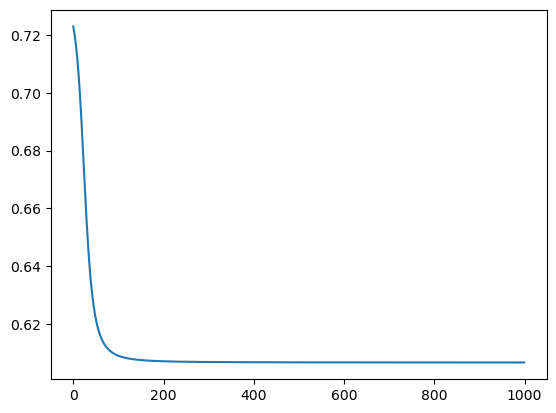

In [18]:
x = [[1,0,0],[1,1,0],
     [1,0,1],[1,1,1]]
yd = [0,1,1,0]

res = multiLearn(x, yd, 1000, 2)
#affichage des poids et des erreurs successives à chaque itération
print("Les poids w1 sont :" + str(res[0]))
print("Les poids w2 sont :" + str(res[1]))
print("Les erreurs successives sont :" + str(res[2])) 
plt.clf()
plt.plot(res[2])